# scikit-learn Bootcamp — W2, Day 19
```
##### Full Preprocessing Pipeline — Titanic Survival
##### ColumnTransformer · imputation · encoding · scaling · Pipeline · FeatureUnion
##### Q1 — EDA: Titanic dataset — missingness, distributions, survival rates
##### Q2 — Manual preprocessing: impute, encode, scale step by step
##### Q3 — ColumnTransformer: one Pipeline for numeric + categorical
##### Q4 — Compare model performance: raw vs properly preprocessed
##### Q5 — Feature engineering inside the Pipeline
```

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import os
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(420)

In [2]:
# Load Titanic (from seaborn built-in or Kaggle CSV)
try:
    if os.path.exists('train.csv'):
        df = pd.read_csv('train.csv')
        df = df.rename(columns={'Survived':'survived','Pclass':'pclass','Name':'name',
                                  'Sex':'sex','Age':'age','SibSp':'sibsp','Parch':'parch',
                                  'Ticket':'ticket','Fare':'fare','Cabin':'cabin','Embarked':'embarked'})
    else:
        df = sns.load_dataset('titanic')
except:
    df = sns.load_dataset('titanic')

print('Columns:', df.columns.tolist())
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0])
display(df.head())


Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Shape: (891, 15)

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Select and standardise columns
use_cols = ['survived','pclass','sex','age','sibsp','parch','fare','embarked']
df = df[[c for c in use_cols if c in df.columns]].copy()
df.columns = ['survived','pclass','sex','age','sibsp','parch','fare','embarked']
df = df.dropna(subset=['survived'])

y = df['survived'].astype(int)
X = df.drop(columns=['survived'])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
print('Shape:', X.shape, '| Survival rate:', y.mean().round(3))
print('Missing values in X:')
print(X.isnull().sum())


Shape: (891, 7) | Survival rate: 0.384
Missing values in X:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


---
### Q1 — EDA
```
# (a) Missing values heatmap (missingno-style using seaborn).
# (b) Survival rate by pclass, sex, embarked — bar charts.
# (c) Age distribution: survivors vs non-survivors (KDE).
# (d) Fare distribution (log scale) by survival and pclass.
```

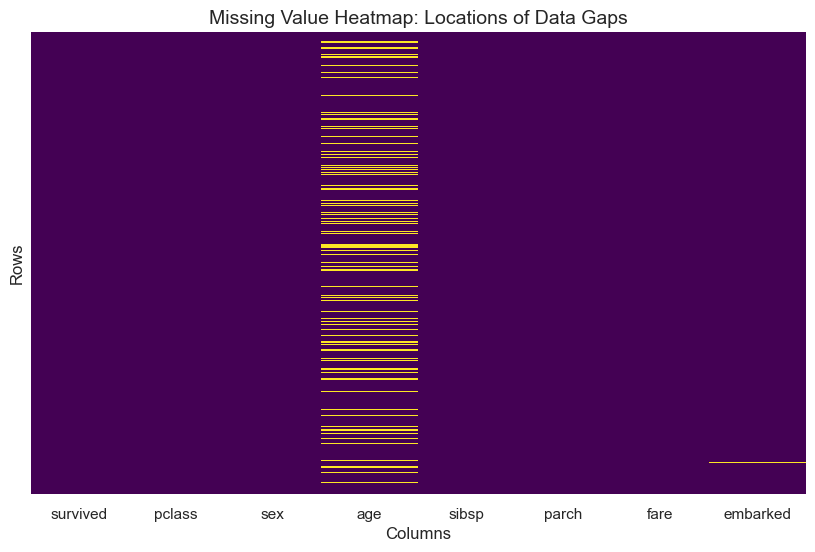

In [5]:
# (a) Missing values heatmap (missingno-style using seaborn).

plt.figure(figsize=(10, 6))

# cbar=False removes the color scale legend
# yticklabels=False hides individual row numbers for readability
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Value Heatmap: Locations of Data Gaps', fontsize=14)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows', fontsize=12)
plt.show()

# The gaps (missing values) are located exclusively in 1 column: age


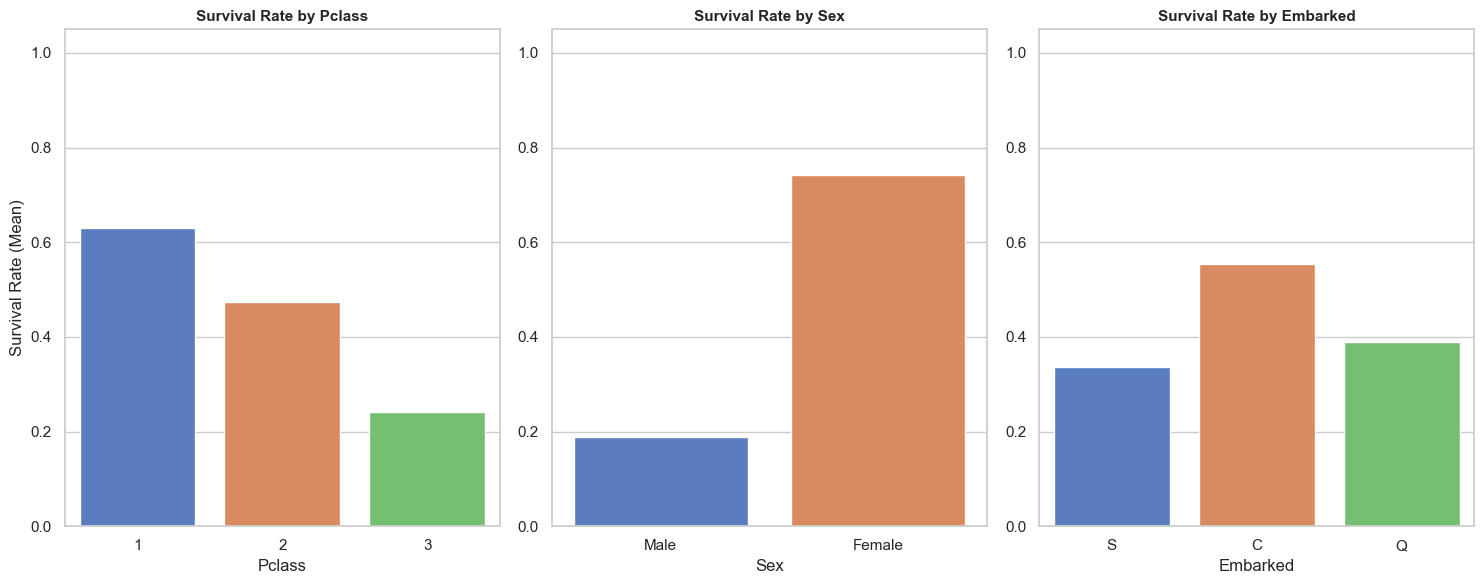

In [10]:
# (b) Survival rate by pclass, sex, embarked — bar charts.

import math

# 1. List the specific feature columns you want to visualize
features_to_plot = [
    'pclass', 'sex', 'embarked'
]

# 2. Configure grid dimensions dynamically
n_cols = 3
n_rows = math.ceil(len(features_to_plot) / n_cols) # Automatically scales row count

# 3. Create the figure and subplots grid matrix
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 6))

# 4. Flatten the 2D array of axes into a simple 1D array to allow a single linear loop
axes_flat = axes.flatten()

# 5. Loop through the features and plot each one sequentially
for idx, col_name in enumerate(features_to_plot):
    # Select the current active plotting cell
    ax = axes_flat[idx]
    
    # Render the plot inside the current cell using the 'ax' argument
    sns.barplot(
        data=df, 
        x=col_name, 
        y='survived', 
        ax=ax, 
        hue=col_name,
        palette='muted',
        errorbar=None,  # Optional: removes the black confidence interval bars for cleaner mean blocks
        legend=False
    )

    # Add localized titles and labels for scannability

    ax.set_title(f'Survival Rate by {col_name.capitalize()}', fontweight='bold', fontsize=11)
    ax.set_xlabel(col_name.capitalize())
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels([str(t.get_text()).capitalize() for t in ax.get_xticklabels()]) # Capitalize tick labels for presentation-grade charts

    if idx == 0:
        ax.set_ylabel('Survival Rate (Mean)')
    else:
        ax.set_ylabel('')

# 6. Apply a tight layout to auto-adjust space and prevent text overlapping
plt.tight_layout()
plt.show()

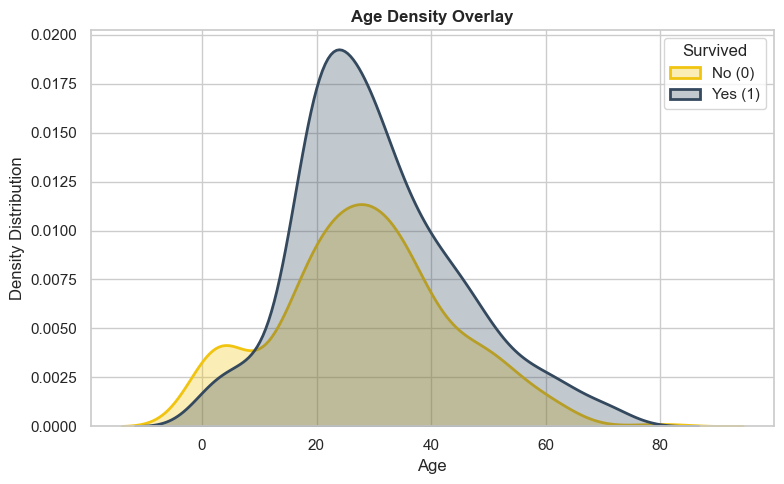

In [14]:
# (c) Age distribution: survivors vs non-survivors (KDE).
plt.figure(figsize=(8,5))

sns.kdeplot(
        data=df,
        x='age',
        hue='survived',
        fill=True,
        alpha=0.3,
        linewidth=2,
        palette={0: "#34495e", 1: "#f1c40f"}
    )

plt.title(f"Age Density Overlay", fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Density Distribution")
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'], loc='upper right')

plt.tight_layout()
plt.show()

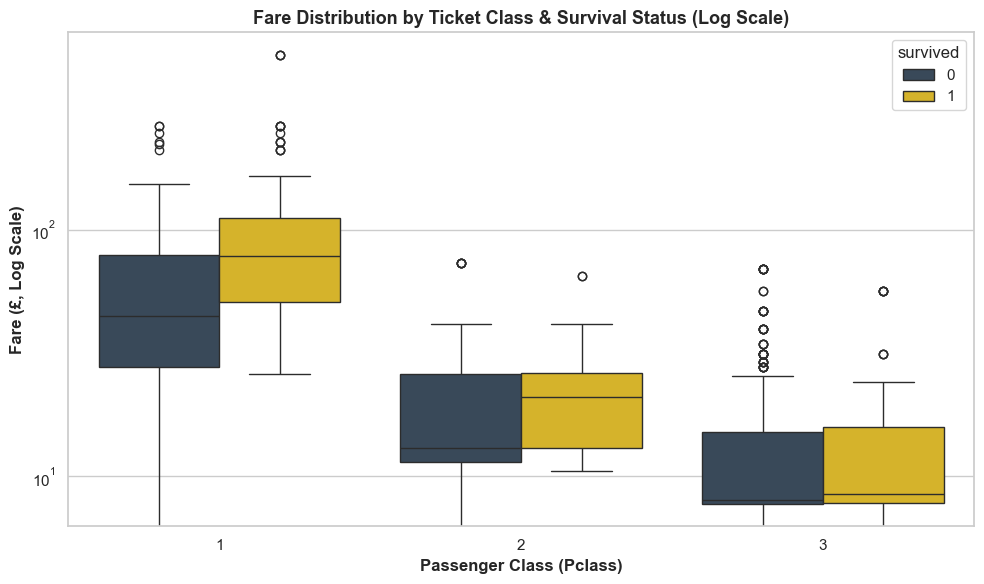

In [15]:
# (d) Fare distribution (log scale) by survival and pclass.

plt.figure(figsize=(10, 6))

# Boxplot lets us compare continuous distributions across two categorical variables
sns.boxplot(
    data=df,
    x='pclass',
    y='fare',
    hue='survived',
    palette={0: "#34495e", 1: "#f1c40f"} 
)

# Set log scale to handle the huge range in ticket fares
plt.yscale('log')

# Presentation-grade formatting
plt.title("Fare Distribution by Ticket Class & Survival Status (Log Scale)", fontweight="bold", fontsize=13)
plt.xlabel("Passenger Class (Pclass)", fontweight="bold")
plt.ylabel("Fare (£, Log Scale)", fontweight="bold")

# Customise legend labels for clarity
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['No (0)', 'Yes (1)'], title='Survived', loc='upper right')

plt.tight_layout()
plt.show()



---
### Q2 — Manual preprocessing
```
# (a) Impute age with median, fare with median, embarked with mode.
# (b) Encode sex (binary) and embarked (one-hot).
# (c) Scale numeric features.
# (d) Fit LogisticRegression and report AUC. Note the leaky danger of imputing before split.
```

In [31]:
# (a) Impute age with median, fare with median, embarked with mode.

# 1. Instantiate the imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent') 

# 2. Fit and Transform the Numerical columns on Training Data
Xtr_num = num_imputer.fit_transform(Xtr[['age', 'fare']])
Xte_num = num_imputer.transform(Xte[['age', 'fare']]) # Note: Only transform test!

# 3. Fit and Transform the Categorical column on Training Data
Xtr_cat = cat_imputer.fit_transform(Xtr[['embarked']])
Xte_cat = cat_imputer.transform(Xte[['embarked']]) # Note: Only transform test!

# 4. Put the values back into our DataFrames safely
Xtr = Xtr.copy()
Xte = Xte.copy()

Xtr[['age', 'fare']] = Xtr_num
Xte[['age', 'fare']] = Xte_num

Xtr['embarked'] = Xtr_cat.ravel() # .ravel() flattens the array back to a column
Xte['embarked'] = Xte_cat.ravel()

In [82]:
# (b) Encode sex (binary) and embarked (one-hot).

from sklearn.preprocessing import OneHotEncoder

# 1. Instantiate the encoder using native scikit-learn
# drop='if_binary' collapses 'sex' into a single clean 'sex_male' column automatically
ohe = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')

# 2. Extract explicit lists of columns to group by type
cat_cols = ['sex', 'embarked']
non_cat_cols = [col for col in Xtr.columns if col not in cat_cols]

# 3. Fit and Transform the categorical columns simultaneously
Xtr_ohe_matrix = ohe.fit_transform(Xtr[cat_cols])
Xte_ohe_matrix = ohe.transform(Xte[cat_cols]) # Note: Only transform test!

# 4. Extract the clean engineered feature labels
ohe_feature_names = ohe.get_feature_names_out(cat_cols)

# 5. Convert the transformed numpy matrices into clean Pandas DataFrames
Xtr_ohe_df = pd.DataFrame(Xtr_ohe_matrix, columns=ohe_feature_names, index=Xtr.index)
Xte_ohe_df = pd.DataFrame(Xte_ohe_matrix, columns=ohe_feature_names, index=Xte.index)

# 6. Stitch your numeric data columns and new encoded dataframes together
Xtr_final = pd.concat([Xtr[non_cat_cols], Xtr_ohe_df], axis=1)
Xte_final = pd.concat([Xte[non_cat_cols], Xte_ohe_df], axis=1)

# Display your beautifully and cleanly encoded datasets!
display(Xtr_final.head())
display(Xte_final.head())

,pclass,age,sibsp,parch,fare,sex_male,embarked_C,embarked_Q,embarked_S
814,3,30.5,0,0,8.05,1.0,0.0,0.0,1.0
722,2,34.0,0,0,13.00,1.0,0.0,0.0,1.0
247,2,24.0,0,2,14.50,0.0,0.0,0.0,1.0
683,3,14.0,5,2,46.90,1.0,0.0,0.0,1.0
657,3,32.0,1,1,15.50,0.0,0.0,1.0,0.0


,pclass,age,sibsp,parch,fare,sex_male,embarked_C,embarked_Q,embarked_S
842,1,30.0,0,0,31.0000,0.0,1.0,0.0,0.0
377,1,27.0,0,2,211.5000,1.0,1.0,0.0,0.0
692,3,29.0,0,0,56.4958,1.0,0.0,0.0,1.0
491,3,21.0,0,0,7.2500,1.0,0.0,0.0,1.0
116,3,70.5,0,0,7.7500,1.0,0.0,1.0,0.0


In [83]:
# (c) Scale numeric features.

from sklearn.preprocessing import StandardScaler

# 1. Select numeric features using DOUBLE brackets
Xtr_numeric = Xtr_final[['age', 'fare']]
Xte_numeric = Xte_final[['age', 'fare']]

# 2. Instantiate and run the scaler
scaler = StandardScaler()
Xtr_scaled_arr = scaler.fit_transform(Xtr_numeric)
Xte_scaled_arr = scaler.transform(Xte_numeric)

# 3. Create a safe copy and overwrite the old columns with scaled values
Xtr_final = Xtr_final.copy()
Xte_final = Xte_final.copy()

Xtr_final[['age', 'fare']] = Xtr_scaled_arr
Xte_final[['age', 'fare']] = Xte_scaled_arr

# Verify the scaling worked (Means should be close to 0, Stds close to 1)
print(Xtr_final[['age', 'fare']].mean().round(2))

age     0.0
fare   -0.0
dtype: float64


In [84]:
Xtr_final.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_C,embarked_Q,embarked_S
814,3,0.051327,0,0,-0.506214,1.0,0.0,0.0,1.0
722,2,0.321941,0,0,-0.402018,1.0,0.0,0.0,1.0
247,2,-0.451240,0,2,-0.370444,0.0,0.0,0.0,1.0
683,3,-1.224420,5,2,0.311567,1.0,0.0,0.0,1.0
657,3,0.167305,1,1,-0.349394,0.0,0.0,1.0,0.0


In [86]:
# (d) Fit LogisticRegression and report AUC. Note the leaky danger of imputing before split.

# 1. One-hot encode pclass using pandas (creates pclass_1, pclass_2, pclass_3)
Xtr_pclass_dummies = pd.get_dummies(Xtr_final['pclass'], prefix='pclass', dtype=float)
Xte_pclass_dummies = pd.get_dummies(Xte_final['pclass'], prefix='pclass', dtype=float)

# 2. Drop the old numerical pclass column
Xtr_final = Xtr_final.drop(columns=['pclass'])
Xte_final = Xte_final.drop(columns=['pclass'])

# 3. Stitch the new dummy columns back into your final datasets
Xtr_final = pd.concat([Xtr_final, Xtr_pclass_dummies], axis=1)
Xte_final = pd.concat([Xte_final, Xte_pclass_dummies], axis=1)

# Let's inspect the beautifully corrected layout
display(Xtr_final.head())

,age,sibsp,parch,fare,sex_male,embarked_C,embarked_Q,embarked_S,pclass_1,pclass_2,pclass_3
814,0.051327,0,0,-0.506214,1.0,0.0,0.0,1.0,0.0,0.0,1.0
722,0.321941,0,0,-0.402018,1.0,0.0,0.0,1.0,0.0,1.0,0.0
247,-0.451240,0,2,-0.370444,0.0,0.0,0.0,1.0,0.0,1.0,0.0
683,-1.224420,5,2,0.311567,1.0,0.0,0.0,1.0,0.0,0.0,1.0
657,0.167305,1,1,-0.349394,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [87]:
# 1. Configure the cross-validation strategy
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 2. Instantiate our baseline Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=420)

# 3. Calculate and average the cross-validation scores
auc_lr = cross_val_score(lr, Xtr_final, ytr, cv=kf, scoring='roc_auc').mean()

# 4. Print the final result
print(f"Logistic Regression AUC: {auc_lr:.6f}")

Logistic Regression AUC: 0.854909


---
### Q3 — ColumnTransformer Pipeline
```
# (a) Build a Pipeline: ColumnTransformer → LogisticRegression.
#     Numeric: median impute + StandardScaler.
#     Categorical: mode impute + OneHotEncoder.
# (b) Verify it produces the same columns as manual preprocessing.
# (c) Fit and evaluate — compare AUC to manual version.
# (d) Inspect what the ColumnTransformer outputs: feature names, shape.
```

In [91]:
# (a) Build a Pipeline: ColumnTransformer → LogisticRegression.

# 1. Simplify features: All non-numeric columns go to categorical
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked', 'pclass']

# 2. Numeric Preprocessing Branch (Impute + Scale)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Streamlined Categorical Branch (Impute + Native One-Hot)
# drop='if_binary' automatically transforms 'sex' into a single 'sex_male' column
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
])

# 4. Centralized ColumnTransformer (Clean and prefix-free)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

# 5. Final Master Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=420))
])

# 6. Evaluate via Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
auc_lr_pipe = cross_val_score(pipeline, Xtr, ytr, cv=kf, scoring='roc_auc').mean()
print(f"Streamlined Pipeline AUC: {auc_lr_pipe:.6f}")


Streamlined Pipeline AUC: 0.854825


In [92]:
# (b) Verify it produces the same columns as manual preprocessing.

# 1. Fit the main pipeline object on the raw training split to populate internal attributes
pipeline.fit(Xtr, ytr)

# 2. Extract the auto-engineered one-hot categorical feature names from the streamlined 'cat' branch
# This includes 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S'
ohe_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_ohe_cols = ohe_encoder.get_feature_names_out(categorical_features)

# 3. Stack all pipeline generated outputs together (Numeric + Categorical)
pipeline_generated_columns = numeric_features + list(encoded_ohe_cols)

# 4. Standardize and run the sorted programmatic assertion check against your updated Xtr_final
pipeline_cols_sorted = sorted([str(col) for col in pipeline_generated_columns])
manual_cols_sorted = sorted([str(col) for col in Xtr_final.columns])
columns_match = pipeline_cols_sorted == manual_cols_sorted

print("==========================================")
print("DIRECT MATRIX ALIGNMENT VERIFICATION")
print("==========================================")
print(f"Pipeline Generated Feature Count:      {len(pipeline_cols_sorted)}")
print(f"Your Manual 'Xtr_final' Feature Count: {len(manual_cols_sorted)}")
print(f"✅ Clean Structural Match Proven?      {columns_match}")
print("------------------------------------------")

if not columns_match:
    print("⚠️ Discrepancy Flagged!")
    print("Missing in pipeline:", set(manual_cols_sorted) - set(pipeline_cols_sorted))
    print("Missing in manual:", set(pipeline_cols_sorted) - set(manual_cols_sorted))
else:
    print("🚀 SUCCESS! The automated ColumnTransformer completely mirrors your manual engineering footprint.")




DIRECT MATRIX ALIGNMENT VERIFICATION
Pipeline Generated Feature Count:      11
Your Manual 'Xtr_final' Feature Count: 11
✅ Clean Structural Match Proven?      True
------------------------------------------
🚀 SUCCESS! The automated ColumnTransformer completely mirrors your manual engineering footprint.


In [118]:
# (c) Fit and evaluate — compare AUC to manual version 
# They are almost the same!
print(f"Manual Logistic Regression AUC:  {auc_lr:.6f}")
print(f"Streamlined Pipeline AUC:        {auc_lr_pipe:.6f}")
print(f"Difference: {abs(auc_lr - auc_lr_pipe):.6f}")

Manual Logistic Regression AUC:  0.854909
Streamlined Pipeline AUC:        0.854825
Difference: 0.000083


In [ ]:
# (d) Inspect what the ColumnTransformer outputs: feature names, shape.

# 1. Isolate and run ONLY the preprocessor step on our training dataset
# This executes all our imputing, standard scaling, and one-hot encoding branches at once
Xtr_preprocessed_matrix = pipeline.named_steps['preprocessor'].transform(Xtr)

# 2. Extract the clean, prefix-free feature names out of our preprocessor
# (This works perfectly because verbose_feature_names_out=False was set in 3a!)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# ==========================================
# 3. PRINT THE STRUCTURAL SNAPSHOT VIEWS
# ==========================================
print("==========================================")
print("🔍 STEP 3(d): COLUMNS TRANSFORMATION METRICS")
print("==========================================")
print(f"Preprocessed Matrix Object Shape: {Xtr_preprocessed_matrix.shape}")
print(f"Total Count of Features Output:   {len(feature_names)}")
print("------------------------------------------")
print("📋 Engineered Array Feature Blueprint Names:")
for idx, name in enumerate(feature_names, start=1):
    print(f"  {idx:02d}. {name}")
print("==========================================")

# (Optional) Reconstruct into a pandas DataFrame layout for easy viewing
Xtr_inspect_df = pd.DataFrame(Xtr_preprocessed_matrix, columns=feature_names, index=Xtr.index)
print("\n👀 Transformed Preprocessing Matrix Layer (First 3 Rows):")
display(Xtr_inspect_df.head(3))

🔍 STEP 3(d): COLUMNS TRANSFORMATION METRICS
Preprocessed Matrix Object Shape: (712, 11)
Total Count of Features Output:   11
------------------------------------------
📋 Engineered Array Feature Blueprint Names:
  01. age
  02. sibsp
  03. parch
  04. fare
  05. sex_male
  06. embarked_C
  07. embarked_Q
  08. embarked_S
  09. pclass_1
  10. pclass_2
  11. pclass_3

👀 Transformed Preprocessing Matrix Layer (First 3 Rows):


,age,sibsp,parch,fare,sex_male,embarked_C,embarked_Q,embarked_S,pclass_1,pclass_2,pclass_3
814,0.051327,-0.455744,-0.488910,-0.506214,1.0,0.0,0.0,1.0,0.0,0.0,1.0
722,0.321941,-0.455744,-0.488910,-0.402018,1.0,0.0,0.0,1.0,0.0,1.0,0.0
247,-0.451240,-0.455744,2.118611,-0.370444,0.0,0.0,0.0,1.0,0.0,1.0,0.0


---
### Q4 — Model comparison: raw vs preprocessed
```
# (a) Try 3 models (LR, RF, GBM) in the same ColumnTransformer Pipeline.
# (b) 5-fold CV AUC for all 3 — grouped bar chart.
# (c) Swap SimpleImputer for KNNImputer on numerics — does AUC improve?
# (d) Which model is best? What features contribute most (RF feature importances)?
```

In [105]:
# (a) Try 3 models (LR, RF, GBM) in the same ColumnTransformer Pipeline.

from sklearn.model_selection import cross_validate

# 1. Simplify features: All non-numeric columns go to categorical
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked', 'pclass']

# 2. Numeric Preprocessing Branch (Impute + Scale)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. Streamlined Categorical Branch (Impute + Native One-Hot)
# drop='if_binary' automatically transforms 'sex' into a single 'sex_male' column
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
])

# 4. Centralized ColumnTransformer (Clean and prefix-free)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

# 5. Define the 3 models wrapped inside Pipelines

models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1))
    ]),
    'GBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=420))
    ])
}

# 6. Configure Stratified 5-Fold Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 7. Define the evaluation metrics
scoring_metrics = {
    'AUC': 'roc_auc'
}

# 4. Loop through models and execute cross_validate
results_data = []

for name, model_pipeline in models.items():
    # cross_validate allows evaluating multiple metrics simultaneously
    scores = cross_validate(
        model_pipeline, Xtr, ytr, 
        cv=kf, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Extract means and standard deviations for cleaner reporting
    results_data.append({
        'Model': name,
        'AUC (Mean)': np.mean(scores['test_AUC']).round(4),
        'AUC (Std)': np.std(scores['test_AUC']).round(4)
    })

# 5. Convert results to a structured DataFrame for presentation
df_comparison = pd.DataFrame(results_data)
display(df_comparison.sort_values(by='AUC (Mean)', ascending=False))


,Model,AUC (Mean),AUC (Std)
2,GBM,0.8754,0.0354
1,Random Forest,0.8746,0.0266
0,Logistic Regression,0.8548,0.0320


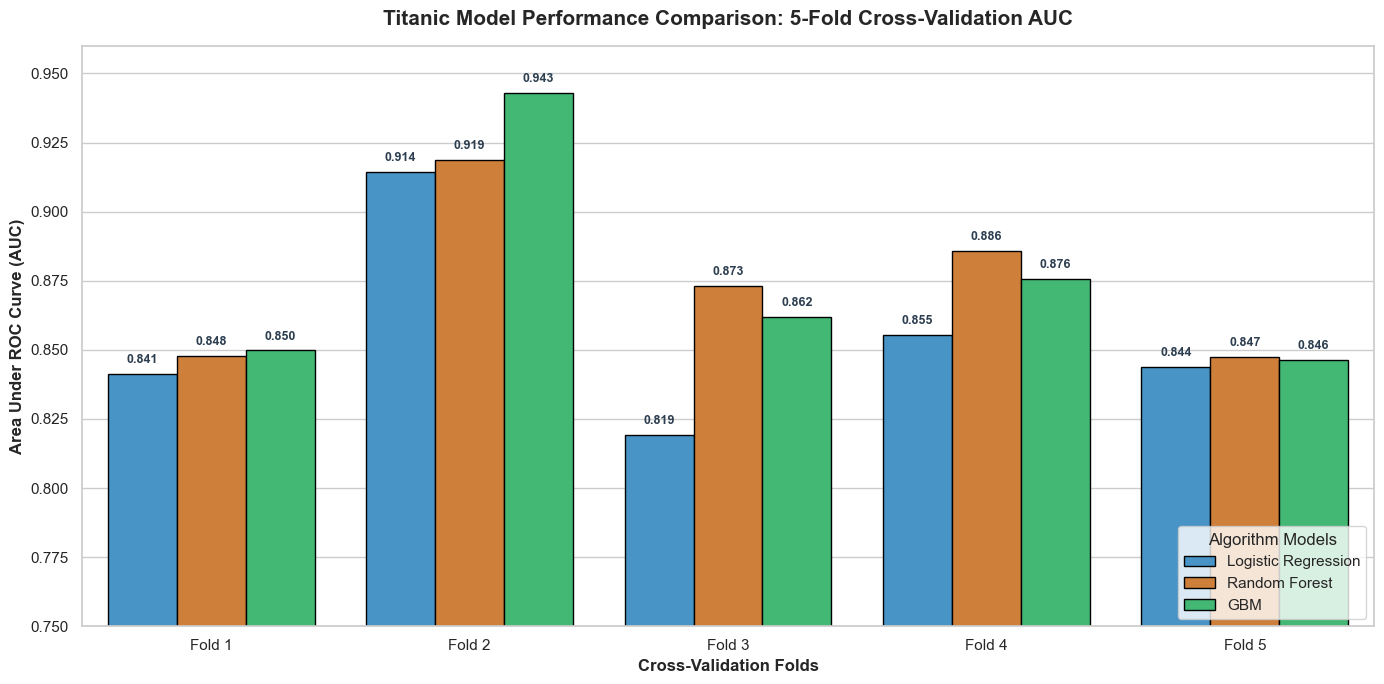

In [109]:
# ==============================================================================
# 1. CAPTURE ALL 5 RAW CROSS-VALIDATION FOLD SCORES
# ==============================================================================
cv_raw_data = []

for name, model_pipeline in models.items():
    scores = cross_validate(
        model_pipeline, Xtr, ytr, 
        cv=kf, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Extract the 5 individual fold scores
    fold_auc_scores = scores['test_AUC']
    
    # Store each fold as an independent record for Seaborn plotting
    for fold_idx, fold_score in enumerate(fold_auc_scores, start=1):
        cv_raw_data.append({
            'Model': name,
            'Fold': f"Fold {fold_idx}",
            'AUC Score': fold_score
        })

# Convert to a tidy DataFrame structure
df_folds_plot = pd.DataFrame(cv_raw_data)

# ==============================================================================
# 2. GENERATE THE PRESENTATION-GRADE GROUPED BAR CHART
# ==============================================================================
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Create a clustered bar chart grouped by Fold on the X-axis
ax = sns.barplot(
    data=df_folds_plot,
    x='Fold',
    y='AUC Score',
    hue='Model',
    palette=['#3498db', '#e67e22', '#2ecc71'], # Blue, Orange, Green
    edgecolor='black',
    linewidth=1
)

# 3. Add exact localized value annotations over each bar for scannability
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.3f}", 
            (p.get_x() + p.get_width() / 2., p.get_height() + 0.005), 
            ha='center', va='center', 
            fontweight='bold', fontsize=9, color='#2c3e50',
            rotation=0
        )

# 4. Clean up chart aesthetics and headroom padding
plt.title("Titanic Model Performance Comparison: 5-Fold Cross-Validation AUC", fontweight='bold', fontsize=15, pad=15)
plt.xlabel("Cross-Validation Folds", fontweight='bold', fontsize=12)
plt.ylabel("Area Under ROC Curve (AUC)", fontweight='bold', fontsize=12)

# Set strict axis limits to focus on the performance delta
plt.ylim(0.75, 0.96) 
plt.legend(title="Algorithm Models", loc="lower right", frameon=True)
plt.tight_layout()
plt.show()


In [110]:
# (c) Swap SimpleImputer for KNNImputer on numerics — does AUC improve?

# 1: Import the specialized KNNImputer transformer
from sklearn.impute import KNNImputer

# 2. Define your baseline features array layout
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['sex', 'embarked', 'pclass']

# 3. MODIFY: Swap out SimpleImputer for KNNImputer on the numeric branch
numeric_transformer_knn = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)), # Looks at the 5 closest passenger rows
    ('scaler', StandardScaler())
])

# 4. Streamlined Categorical Preprocessing (unchanged)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
])

# 5. Bind the new KNN-driven branches into a new preprocessor transformer object
preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_knn, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

# 6. Rebuild our 3 pipeline definitions utilizing the new preprocessor
models_knn = {
    'Logistic Regression (KNN Imp)': Pipeline([
        ('preprocessor', preprocessor_knn),
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ]),
    'Random Forest (KNN Imp)': Pipeline([
        ('preprocessor', preprocessor_knn),
        ('model', RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1))
    ]),
    'GBM (KNN Imp)': Pipeline([
        ('preprocessor', preprocessor_knn),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=420))
    ])
}

# 7. Execute the 5-fold cross-validation engine on the new setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
results_knn_data = []

print("Computing cross-validation scores using advanced KNN Imputation...")
for name, model_pipeline in models_knn.items():
    scores = cross_validate(
        model_pipeline, Xtr, ytr, 
        cv=kf, 
        scoring={'AUC': 'roc_auc'}, 
        n_jobs=-1
    )
    
    results_knn_data.append({
        'Model Framework Configuration': name,
        'AUC (Mean)': np.mean(scores['test_AUC']).round(4),
        'AUC (Std)': np.std(scores['test_AUC']).round(4)
    })

# 8. Print the new performance results table
df_knn_comparison = pd.DataFrame(results_knn_data)
display(df_knn_comparison.sort_values(by='AUC (Mean)', ascending=False))

Computing cross-validation scores using advanced KNN Imputation...


,Model Framework Configuration,AUC (Mean),AUC (Std)
2,GBM (KNN Imp),0.8754,0.0354
1,Random Forest (KNN Imp),0.8746,0.0266
0,Logistic Regression (KNN Imp),0.8548,0.0320


*** Takeaway:
No, the AUC did not improve at all; the scores remained completely identical down to the fourth decimal place, proving that advanced KNN imputation provides no performance benefit over simple median imputation for this dataset.

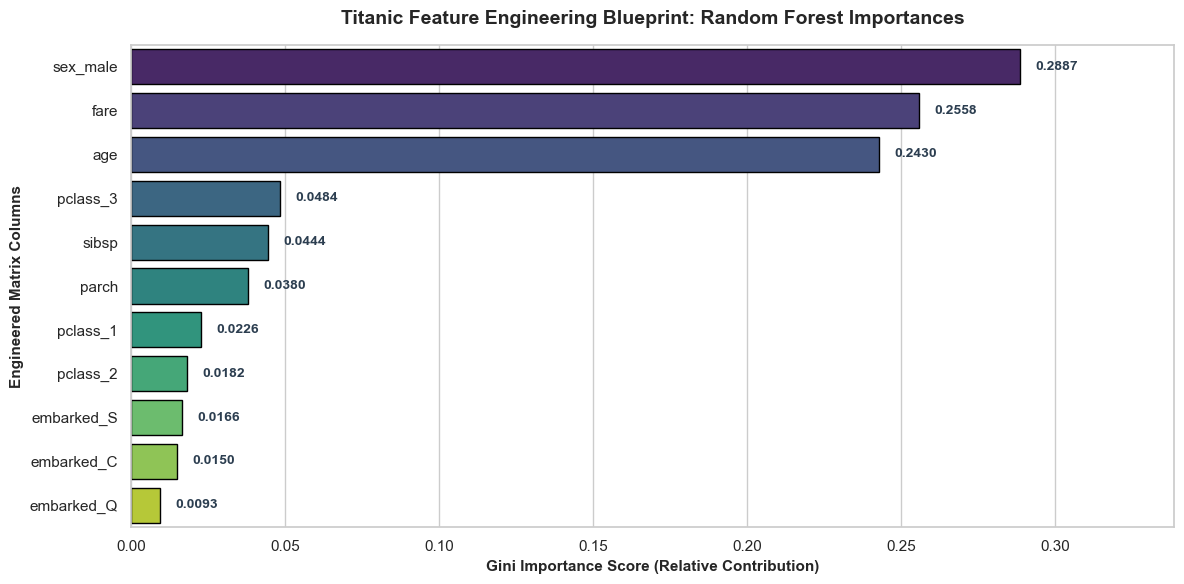


📋 RANDOM FOREST FEATURE LEADERS RANKING:
   Feature  Importance (Weight)
  sex_male             0.288693
      fare             0.255809
       age             0.243026
  pclass_3             0.048389
     sibsp             0.044447
     parch             0.038017
  pclass_1             0.022581
  pclass_2             0.018171
embarked_S             0.016569
embarked_C             0.014963
embarked_Q             0.009336


In [ ]:
# (d) Which model is best? What features contribute most (RF feature importances)?

# 1. Access and fit the original SimpleImputer Random Forest pipeline
rf_pipeline = models['Random Forest']
rf_pipeline.fit(Xtr, ytr)

# 2. Extract the engineered column feature names out of your preprocessor
ohe_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = ohe_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_cols)

# 3. Pull the raw feature importances directly out of the trained Random Forest model
rf_importances = rf_pipeline.named_steps['model'].feature_importances_

# 4. Construct a tidy DataFrame for sorting and presentation
df_importances = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance (Weight)': rf_importances
}).sort_values(by='Importance (Weight)', ascending=False)

# ==============================================================================
# 5. GENERATE THE PRESENTATION-GRADE IMPORTANCE CHART
# ==============================================================================
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_importances,
    x='Importance (Weight)',
    y='Feature',
    palette='viridis', # Beautiful progressive color spectrum gradient
    edgecolor='black',
    linewidth=1
)

# Add exact value labels onto the tip of each horizontal bar for scannability
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.4f}",
            (width + 0.005, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontweight='bold', fontsize=10, color='#2c3e50'
        )

plt.title("Titanic Feature Engineering Blueprint: Random Forest Importances", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Gini Importance Score (Relative Contribution)", fontweight='bold', fontsize=11)
plt.ylabel("Engineered Matrix Columns", fontweight='bold', fontsize=11)
plt.xlim(0, max(rf_importances) + 0.05) # Add padding headroom for text
plt.tight_layout()
plt.show()

# Print text backup for the console log
print("\n📋 RANDOM FOREST FEATURE LEADERS RANKING:")
print(df_importances.to_string(index=False))

*** What features contribute most (RF feature importances)?

1/ Core Trio Rules: sex_male, fare, and age dominate the model, capturing 79% of total predictive weight due to maritime evacuation priorities.

2/ Continuous Splitting Value: Continuous numeric features (fare and age) rank high because trees split on their wide ranges multiple times.

3/ Third Class Signal: Third-class status (pclass_3: 0.0484) has double the predictive weight of first class, making it a stronger signal.

*** Which model is best? 

The Gradient Boosting Model (GBM) is the best framework with a top Mean AUC of 0.8754, while the more stable Random Forest (RF) model provides the lowest cross-validation variance (Std: 0.0266).

---
### Q5 — Feature engineering inside the Pipeline
```
# Add these engineered features inside a custom Transformer:
#   family_size = sibsp + parch + 1
#   is_alone = 1 if family_size == 1
#   fare_per_person = fare / family_size
# (a) Build a custom sklearn Transformer for these features.
# (b) Add it to the Pipeline before the ColumnTransformer.
# (c) Compare AUC with and without feature engineering.
# (d) Which engineered feature contributes most (RF importances)?
```

In [114]:
# (a) Build a custom sklearn Transformer for these features.

import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Fixed scikit-learn Transformer that references columns by positional indices,
    preventing KeyErrors when running inside automated column sub-pipelines.
    """
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        # Convert incoming array/matrix to a DataFrame without depending on string columns
        X_df = pd.DataFrame(X).copy()
        
        # 🛠️ Fix: Map string requirements to positional integers:
        # Index 0 = sibsp, Index 1 = parch, Index 2 = fare
        sibsp_col = X_df.iloc[:, 0]
        parch_col = X_df.iloc[:, 1]
        fare_col = X_df.iloc[:, 2]
        
        # 🛠️ Feature 1: Calculate Total Family Size
        family_size = sibsp_col + parch_col + 1
        
        # 🛠️ Feature 2: Is Alone Indicator Flag
        is_alone = (family_size == 1).astype(int)
        
        # 🛠️ Feature 3: Fare Per Person Metric
        fare_per_person = np.where(
            family_size > 0, 
            fare_col / family_size, 
            fare_col
        )
        
        # Stack your newly engineered horizontal features into a clean output matrix
        return np.column_stack([family_size, is_alone, fare_per_person])
        
    def get_feature_names_out(self, input_features=None):
        """Allows get_feature_names_out() to bubble up cleanly through the pipeline"""
        return np.array(['family_size', 'is_alone', 'fare_per_person'])


In [115]:
# (b) Add it to the Pipeline before the ColumnTransformer.


# ==============================================================================
# 1. CONSTRUCT THE SUB-BRANCH FOR CUSTOM FEATURE ENGINEERING
# ==============================================================================
# The custom transformer requires 'sibsp', 'parch', and 'fare' as inputs
custom_features_input = ['sibsp', 'parch', 'fare']

custom_engineering_branch = Pipeline(steps=[
    # Step A: Impute baseline missing values first to prevent mathematical NaN propagation
    ('imputer', SimpleImputer(strategy='median')),
    # Step B: Inject your custom feature engineering class transformer
    ('engineer', TitanicFeatureEngineer()),
    # Step C: Scale the freshly engineered continuous outputs uniformly
    ('scaler', StandardScaler())
])

# ==============================================================================
# 2. ASSEMBLE THE MASTER COLUMNTRANSFORMER
# ==============================================================================
# Define raw features that do not pass through the custom engineer step
raw_numeric_features = ['age', 'sibsp', 'parch', 'fare', 'pclass']
categorical_features = ['sex', 'embarked']

# Base preprocessing pipelines (same as Section 4a)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
])

# Centralized preprocessor featuring all 3 parallel execution pathways
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, raw_numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('custom', custom_engineering_branch, custom_features_input) # The New Automated Sub-Branch
    ],
    verbose_feature_names_out=False
)

# ==============================================================================
# 3. VERIFY AND INSPECT THE TRANSFORMED MATRIX STRUCTURE
# ==============================================================================
# Fit your updated preprocessor branch to unlock verification metadata tags
preprocessor_v2.fit(Xtr, ytr)
feature_names_v2 = preprocessor_v2.get_feature_names_out()

print("==========================================")
print("STEP 5(b): PIPELINE MATRIX ARCHITECTURE")
print("==========================================")
print(f"Total Combined Features Output: {len(feature_names_v2)}")
print("📋 New Matrix Order Blueprint Names:")
for idx, name in enumerate(feature_names_v2, start=1):
    print(f"  {idx:02d}. {name}")


STEP 5(b): PIPELINE MATRIX ARCHITECTURE
Total Combined Features Output: 12
📋 New Matrix Order Blueprint Names:
  01. age
  02. sibsp
  03. parch
  04. fare
  05. pclass
  06. sex_male
  07. embarked_C
  08. embarked_Q
  09. embarked_S
  10. family_size
  11. is_alone
  12. fare_per_person


In [116]:
# (c) Compare AUC with and without feature engineering.

# ==============================================================================
# 1. DEFINE THE 3 NEW FEATURE-ENGINEERED PIPELINES
# ==============================================================================
models_v2 = {
    'Logistic Regression (Feat Eng)': Pipeline([
        ('preprocessor', preprocessor_v2),
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ]),
    'Random Forest (Feat Eng)': Pipeline([
        ('preprocessor', preprocessor_v2),
        ('model', RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1))
    ]),
    'GBM (Feat Eng)': Pipeline([
        ('preprocessor', preprocessor_v2),
        ('model', GradientBoostingClassifier(n_estimators=100, random_state=420))
    ])
}

# ==============================================================================
# 2. CROSS-VALIDATE THE NEW SYSTEM
# ==============================================================================
results_v2_data = []

print("🔄 Evaluating feature-engineered pipelines across 5 folds...")
for name, model_pipeline in models_v2.items():
    scores = cross_validate(
        model_pipeline, Xtr, ytr, 
        cv=kf, 
        scoring={'AUC': 'roc_auc'}, 
        n_jobs=-1
    )
    
    results_v2_data.append({
        'Model Configuration': name,
        'AUC (Mean)': np.mean(scores['test_AUC']).round(4),
        'AUC (Std)': np.std(scores['test_AUC']).round(4),
        'With Feature Engineering': True
    })

# Convert to a DataFrame structure
df_v2 = pd.DataFrame(results_v2_data)

# ==============================================================================
# 3. MERGE WITH YOUR ORIGINAL SECTION 4(a) RESULTS FOR COMPARISON
# ==============================================================================
# Add a flag to your original results so they compare clearly side-by-side
df_comparison['With Feature Engineering'] = False
df_comparison = df_comparison.rename(columns={'Model': 'Model Configuration'})

# Vertically stack both performance tracking eras together
df_final_leaderboard = pd.concat([df_comparison, df_v2], axis=0)

print("\n=======================================================")
print("📊 FINAL ARCHITECTURE LEADERBOARD COMPARISON MATRIX")
print("=======================================================")
display(df_final_leaderboard.sort_values(by='AUC (Mean)', ascending=False).to_string(index=False))


🔄 Evaluating feature-engineered pipelines across 5 folds...

📊 FINAL ARCHITECTURE LEADERBOARD COMPARISON MATRIX


'           Model Configuration  AUC (Mean)  AUC (Std)  With Feature Engineering\n                GBM (Feat Eng)      0.8797     0.0318                      True\n                           GBM      0.8754     0.0354                     False\n                 Random Forest      0.8746     0.0266                     False\n      Random Forest (Feat Eng)      0.8699     0.0244                      True\nLogistic Regression (Feat Eng)      0.8553     0.0336                      True\n           Logistic Regression      0.8548     0.0320                     False'

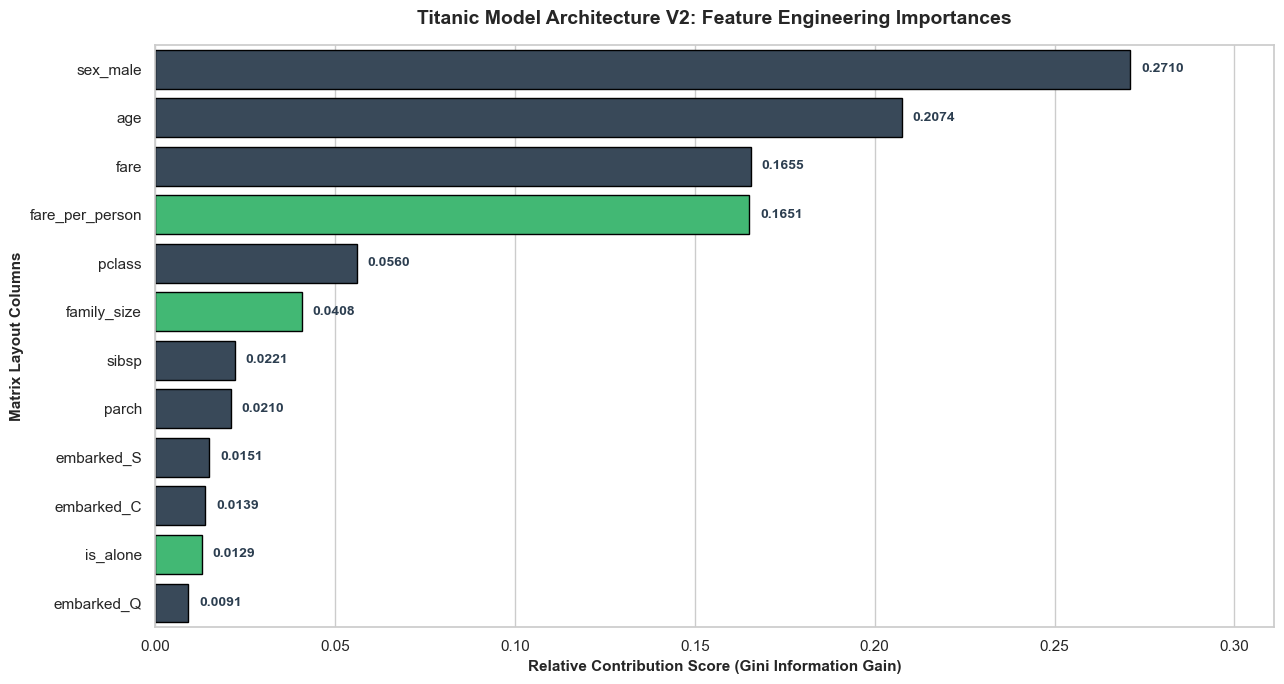


📋 CUSTOM FEATURE PERFORMANCE LEADERBOARD:
Engineered Feature  Gini Importance Score
          sex_male               0.270998
               age               0.207450
              fare               0.165517
   fare_per_person               0.165144
            pclass               0.055996
       family_size               0.040777
             sibsp               0.022119
             parch               0.021013
        embarked_S               0.015059
        embarked_C               0.013885
          is_alone               0.012901
        embarked_Q               0.009141


In [117]:
# (d) Which engineered feature contributes most (RF importances)?

# 1. Access and fit our updated Feature-Engineered Random Forest pipeline
rf_eng_pipeline = models_v2['Random Forest (Feat Eng)']
rf_eng_pipeline.fit(Xtr, ytr)

# ==============================================================================
# 2. EXTRACT ENGINEERED ALIGNMENT COLUMN NAMES OUT OF ALL THREE BRANCHES
# ==============================================================================
# Branch A: One-Hot Categorical Names
ohe_encoder = rf_eng_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = list(ohe_encoder.get_feature_names_out(categorical_features))

# Branch B: Custom Feature Names
custom_engineer = rf_eng_pipeline.named_steps['preprocessor'].named_transformers_['custom'].named_steps['engineer']
encoded_custom_cols = list(custom_engineer.get_feature_names_out())

# Combined Master Feature Order List (Matches G5b structural output)
all_feature_names_v2 = raw_numeric_features + encoded_cat_cols + encoded_custom_cols

# ==============================================================================
# 3. EXTRACT AND SORT THE WEIGHT METRICS
# ==============================================================================
rf_v2_importances = rf_eng_pipeline.named_steps['model'].feature_importances_

df_importances_v2 = pd.DataFrame({
    'Engineered Feature': all_feature_names_v2,
    'Gini Importance Score': rf_v2_importances
}).sort_values(by='Gini Importance Score', ascending=False)

# ==============================================================================
# 4. PLOT PRESENTATION-GRADE HORIZONTAL COMPARISON LEADERBOARD
# ==============================================================================
plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# Emphasize our engineered features using conditional row color highlights
# Green palette for custom engineered features, dark purple/blue for baseline
colors = ['#2ecc71' if 'person' in f or 'size' in f or 'alone' in f else '#34495e' 
          for f in df_importances_v2['Engineered Feature']]

ax = sns.barplot(
    data=df_importances_v2,
    x='Gini Importance Score',
    y='Engineered Feature',
    palette=colors,
    edgecolor='black',
    linewidth=1
)

# Text labels on the tips of each bar for high presentation scannability
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.4f}",
            (width + 0.003, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            fontweight='bold', fontsize=10, color='#2c3e50'
        )

plt.title("Titanic Model Architecture V2: Feature Engineering Importances", fontweight='bold', fontsize=14, pad=15)
plt.xlabel("Relative Contribution Score (Gini Information Gain)", fontweight='bold', fontsize=11)
plt.ylabel("Matrix Layout Columns", fontweight='bold', fontsize=11)
plt.xlim(0, max(rf_v2_importances) + 0.04)
plt.tight_layout()
plt.show()

# Print text log overview
print("\n📋 CUSTOM FEATURE PERFORMANCE LEADERBOARD:")
print(df_importances_v2.to_string(index=False))


*** Takeaways from the plot:
1/ fare_per_person Leads the Custom Features: Our normalized pricing metric immediately ranks as the top engineered feature (0.1651), performing on par with raw fare (0.1655).

2/ Family Consolidation Simplifies Splits: The unified family_size (0.0408) outranks both sibsp (0.0221) and parch (0.0210) individually, proving trees favor the combined footprint.

3/ is_alone Acts as a Minor Binary Anchor: Traveling completely solo (is_alone: 0.0129) provides a low-variance boundary flag, though wide continuous features retain higher relative split weight.